### Linear Regression with Unknown Noise

[`bilby`](https://bilby-dev.github.io/bilby/index.html) is a user-friendly parameter estimation library primarily designed for gravitational wave inference, but applicable to more general problems. This notebook demonstrates how to use it to fit a linear function to data with Gaussian noise of unknown variance, and is largely based on [this example script](https://github.com/bilby-dev/bilby/blob/main/examples/core_examples/linear_regression_unknown_noise.py).

In [1]:
# running this cell for the first time might take a little while
import bilby
import matplotlib.pyplot as plt
import numpy as np
from bilby.core.utils import random
import pandas as pd

In [2]:
# we need to switch off some bilby warnings
import warnings
warnings.filterwarnings("ignore",category=FutureWarning,module="bilby")

In [3]:
# These lines make plots look nicer
font_value = 20

# Set global Matplotlib settings for a clean look without grids
plt.rcParams['axes.grid'] = False      # Disable grid lines for all axes
plt.rcParams['grid.color'] = 'none'    # Just in case, ensure grid color is invisible
# Set matplotlib to render LaTeX fonts
plt.rcParams.update({
    "mathtext.fontset" : "stix",
    "font.family" : "STIXGeneral",
    "axes.labelsize": font_value ,           # Font size for axis labels
    "axes.titlesize": font_value ,           # Font size for titles
    "font.size": font_value ,                # General font size
    "legend.fontsize": font_value ,          # Font size for legend
    "xtick.labelsize": font_value ,          # Font size for x-axis ticks
    "ytick.labelsize": font_value ,          # Font size for y-axis ticks
})

# the following lines are necessary on Macs to make plot look even nicer
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina") # Enable retina display output in Jupyter

In [4]:
# Sets seed to ensure reproducibility
random.seed(42)

In [5]:
# A few simple setup steps
label = "linear_regression_unknown_noise"
outdir = "outdir_v2"
bilby.utils.check_directory_exists_and_if_not_mkdir(outdir)

### Parametric model

First, we define our signal model, in this case a simple linear function

$y(t) = m ~ t + c$

In [6]:
def model(time, m, c):
    return time * m + c

In [7]:
# Now we define the injection parameters which we make simulated data with
injection_parameters = dict(m=0.5, c=0.2)

In [8]:
# For this example, we'll inject standard Gaussian noise
sigma = 5

The next cell generates the fake data. 

Note the ** just unpacks the contents of the `injection_parameters` dictionary when calling the model function.

In [9]:
sampling_frequency = 10
time_duration = 10
time = np.arange(0, time_duration, 1 / sampling_frequency)
N = len(time)
data = model(time, **injection_parameters) + random.rng.normal(0, sigma, N)

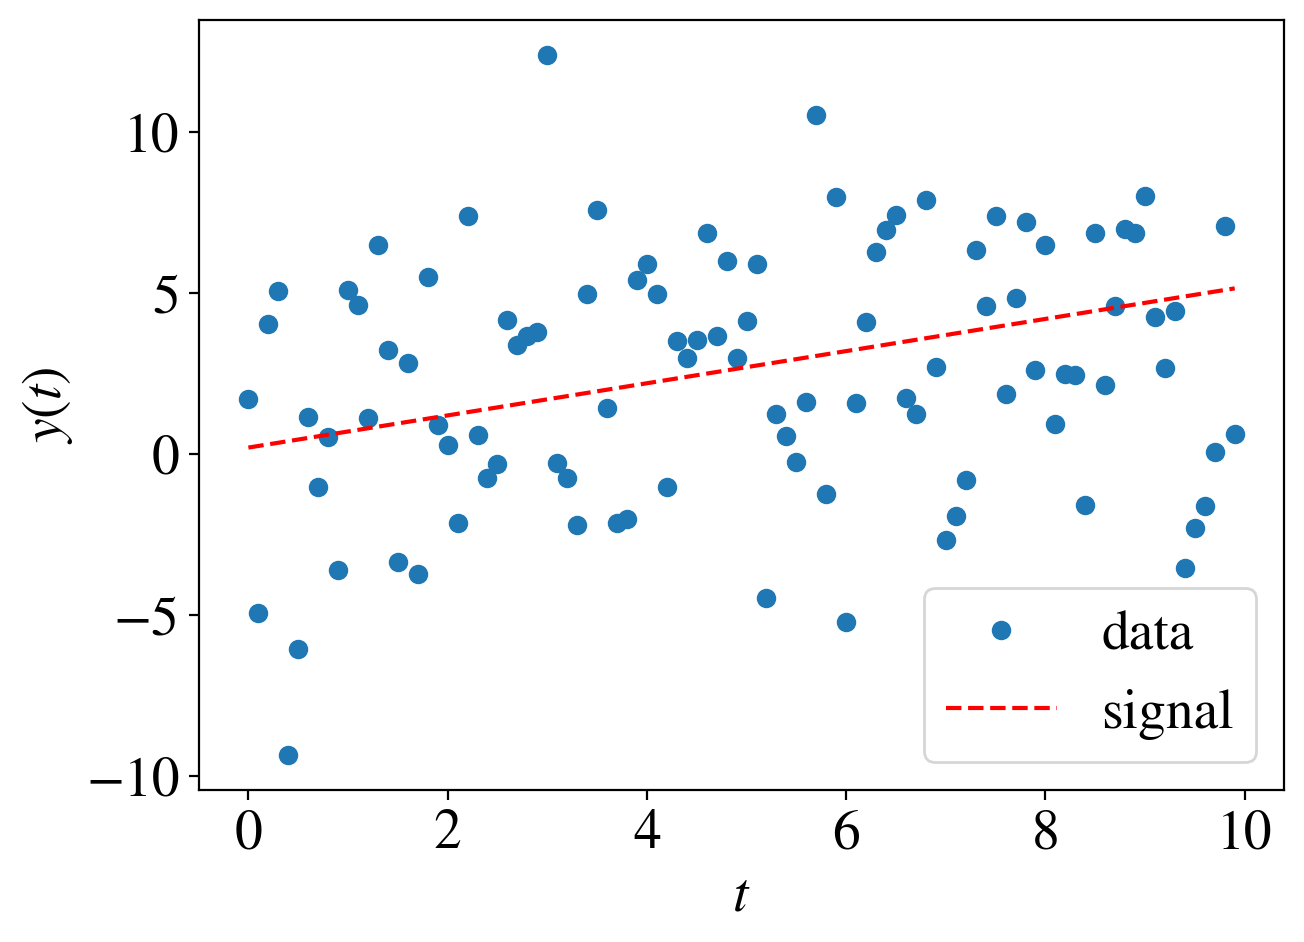

In [10]:
# We quickly plot the data to check it looks sensible
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(time, data, "o", label="data")
ax.plot(time, model(time, **injection_parameters), "--r", label="signal")
ax.set_xlabel("$t$")
ax.set_ylabel("$y(t)$")
ax.legend(fancybox=True)
fig.savefig("{}/{}_data.png".format(outdir, label), dpi = 300)

In [11]:
injection_parameters.update(dict(sigma=sigma))

In [12]:
injection_parameters

{'m': 0.5, 'c': 0.2, 'sigma': 5}

### Bayes' Theorem

As seen during lectures, sampling algorithms such as those based on Markov Chain Monte Carlo (MCMC) are used to explore a posterior distribution defined via Bayes' theorem:

$$p(\theta|d) = \frac{\mathcal{L}(d|\theta)\,\pi(\theta)}{\mathcal{Z}(d)}$$

The parameters we want to infer are $\theta = \{m, c, \sigma\}$. The data are $N$ observations $d = \{t_i, y_i\}_{i=1}^{N}$, where each $y_i$ is modelled as

$$y_i = m\,t_i + c + n_i, \qquad n_i \sim \mathcal{N}(0, \sigma^2).$$

The **likelihood** $\mathcal{L}(d|\theta)$ quantifies the probability of observing the data given a set of parameters. For a single data point, assuming Gaussian noise:

$$\mathcal{L}(y_i | t_i, \theta) = \frac{1}{\sqrt{2\pi\sigma^{2}}} \exp\!\left(\frac{-(y_i - \mu(t_i;\theta))^2}{2\sigma^2}\right),$$

where $\mu(t_i; \theta) = m\,t_i + c$ is the noise-free model prediction. The joint likelihood over all $N$ data points is then

$$\mathcal{L}(d|\theta) = \prod_{i=1}^{N} \mathcal{L}(y_i | t_i, \theta).$$

The **prior** $\pi(\theta)$ encodes our knowledge of the parameters before observing any data. The **evidence** $\mathcal{Z}(d)$, also called the marginalised likelihood, is defined as

$$\mathcal{Z}(d) = \int \mathcal{L}(d|\theta)\,\pi(\theta)\,\mathrm{d}\theta,$$

and plays a central role in Bayesian inference, for instance in model comparison. It cannot, however, be estimated directly using MCMC.

We can now instantiate the built-in [GaussianLikelihood](https://github.com/bilby-dev/bilby/blob/main/bilby/core/likelihood.py#L284-L343) in `bilby`, passing it the time array, the data, and the signal model.

In [13]:
likelihood = bilby.core.likelihood.GaussianLikelihood(time, data, model)

and set the priors

In [14]:
priors = dict()
priors["m"] = bilby.core.prior.Uniform(0, 5, "m")
priors["c"] = bilby.core.prior.Uniform(-2, 2, "c")
priors["sigma"] = bilby.core.prior.Uniform(0, 15, "sigma")

### Running the sampler

With the likelihood and priors defined, we can run the sampler via `run_sampler`, passing the likelihood, priors, and choice of sampler — in this case [`emcee`](https://emcee.readthedocs.io/en/stable/), a widely used MCMC sampler. The remaining arguments control the sampling settings, such as `nsteps` and `nwalkers`.

In [15]:
# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="emcee",
    # MCMC sampling settings
    nsteps=1_000,
    nwalkers=10,
    injection_parameters=injection_parameters,
    outdir=outdir,
    label=label,
    clean=True, 
)

10:56 bilby INFO    : Running for label 'linear_regression_unknown_noise', output will be saved to 'outdir_v2'
10:56 bilby INFO    : Analysis priors:
10:56 bilby INFO    : m=Uniform(minimum=0, maximum=5, name='m', latex_label='m', unit=None, boundary=None)
10:56 bilby INFO    : c=Uniform(minimum=-2, maximum=2, name='c', latex_label='c', unit=None, boundary=None)
10:56 bilby INFO    : sigma=Uniform(minimum=0, maximum=15, name='sigma', latex_label='sigma', unit=None, boundary=None)
10:56 bilby INFO    : Analysis likelihood class: <class 'bilby.core.likelihood.GaussianLikelihood'>
10:56 bilby INFO    : Analysis likelihood noise evidence: nan
10:56 bilby INFO    : Single likelihood evaluation took 3.410e-05 s
10:56 bilby INFO    : Using sampler Emcee with kwargs {'nwalkers': 10, 'a': 2, 'args': [], 'kwargs': {}, 'postargs': None, 'pool': None, 'live_dangerously': False, 'runtime_sortingfn': None, 'lnprob0': None, 'rstate0': None, 'blobs0': None, 'iterations': 1000, 'thin': 1, 'storechain':

### Corner Plot

A corner plot displays the one- and two-dimensional marginal distributions of the sampled parameters, making it a powerful diagnostic tool for identifying correlations between them.

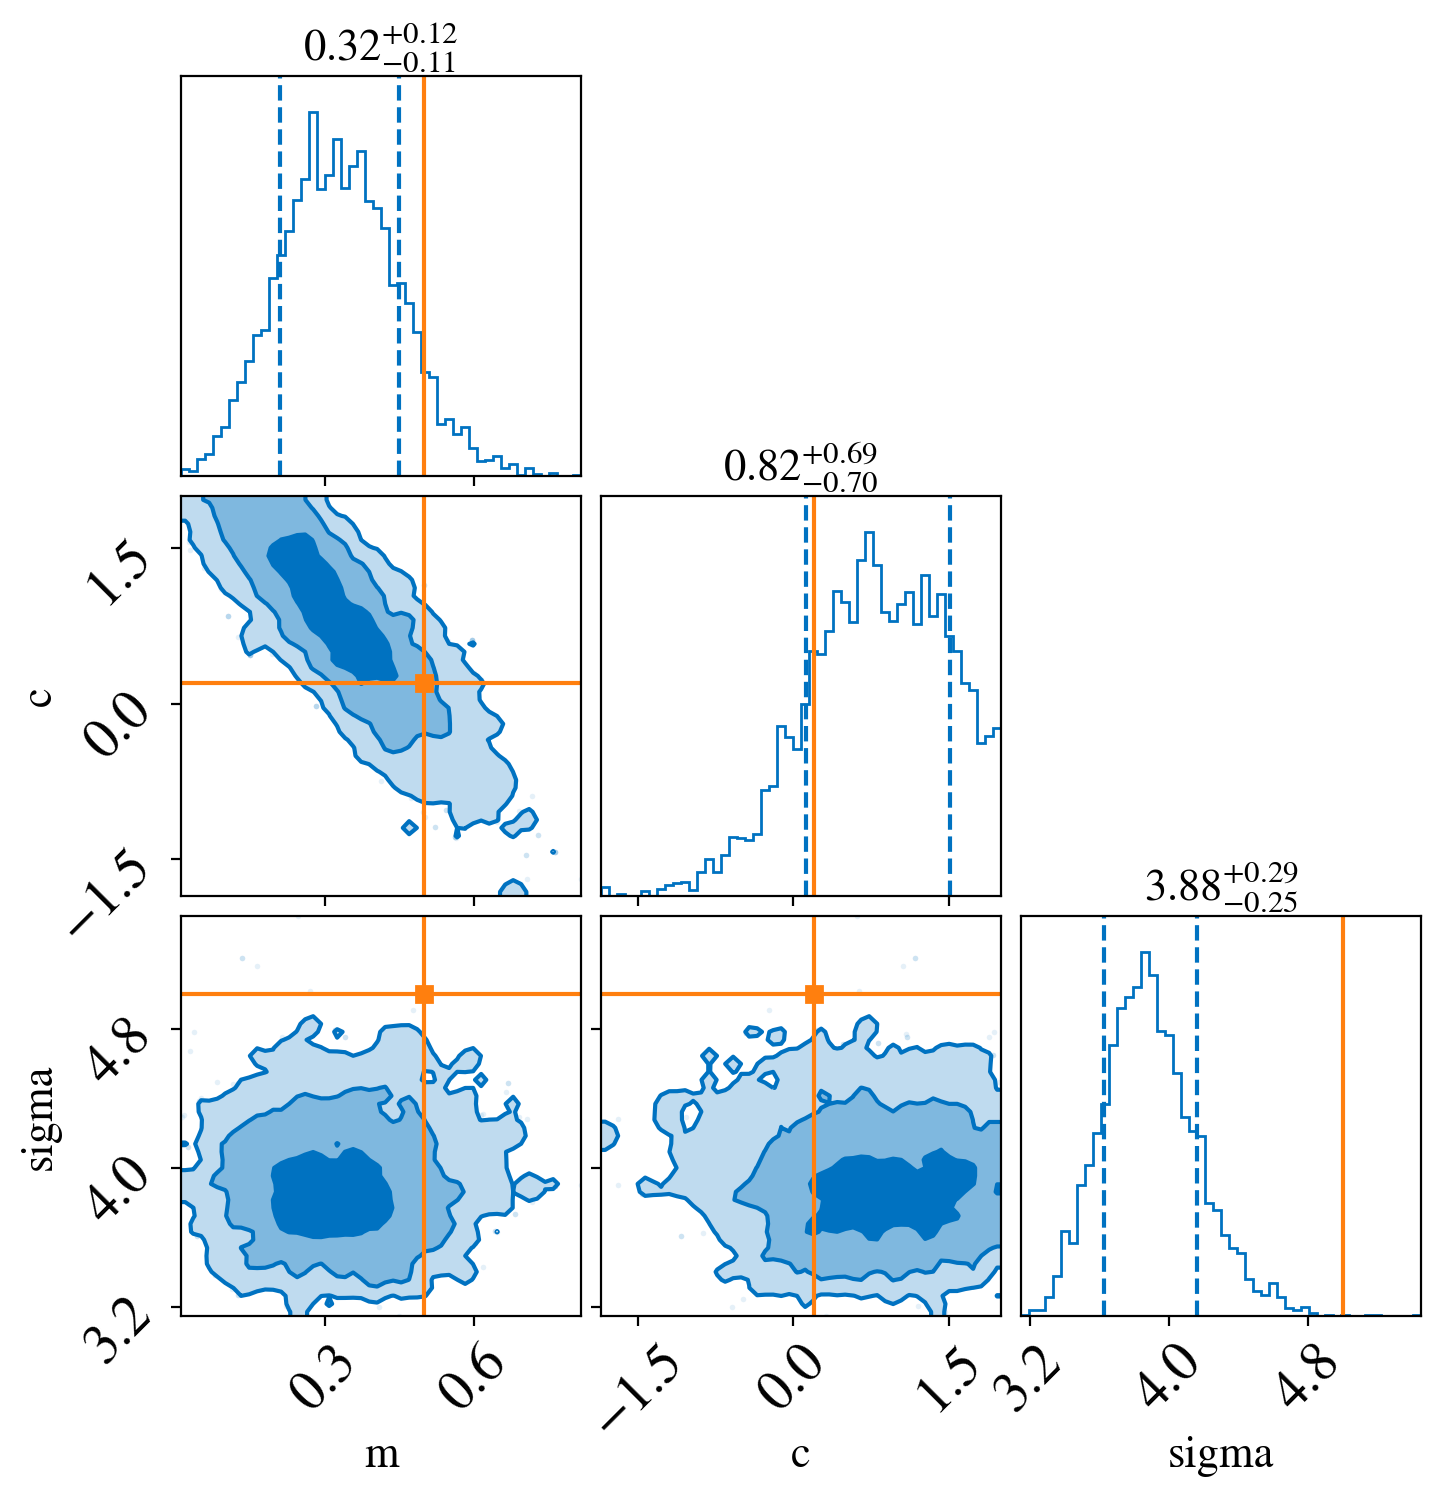

In [16]:

result.plot_corner()

In [17]:
# We select a subset of all posterior samples
posterior_samples = result.posterior.sample(1_000, random_state = 42)

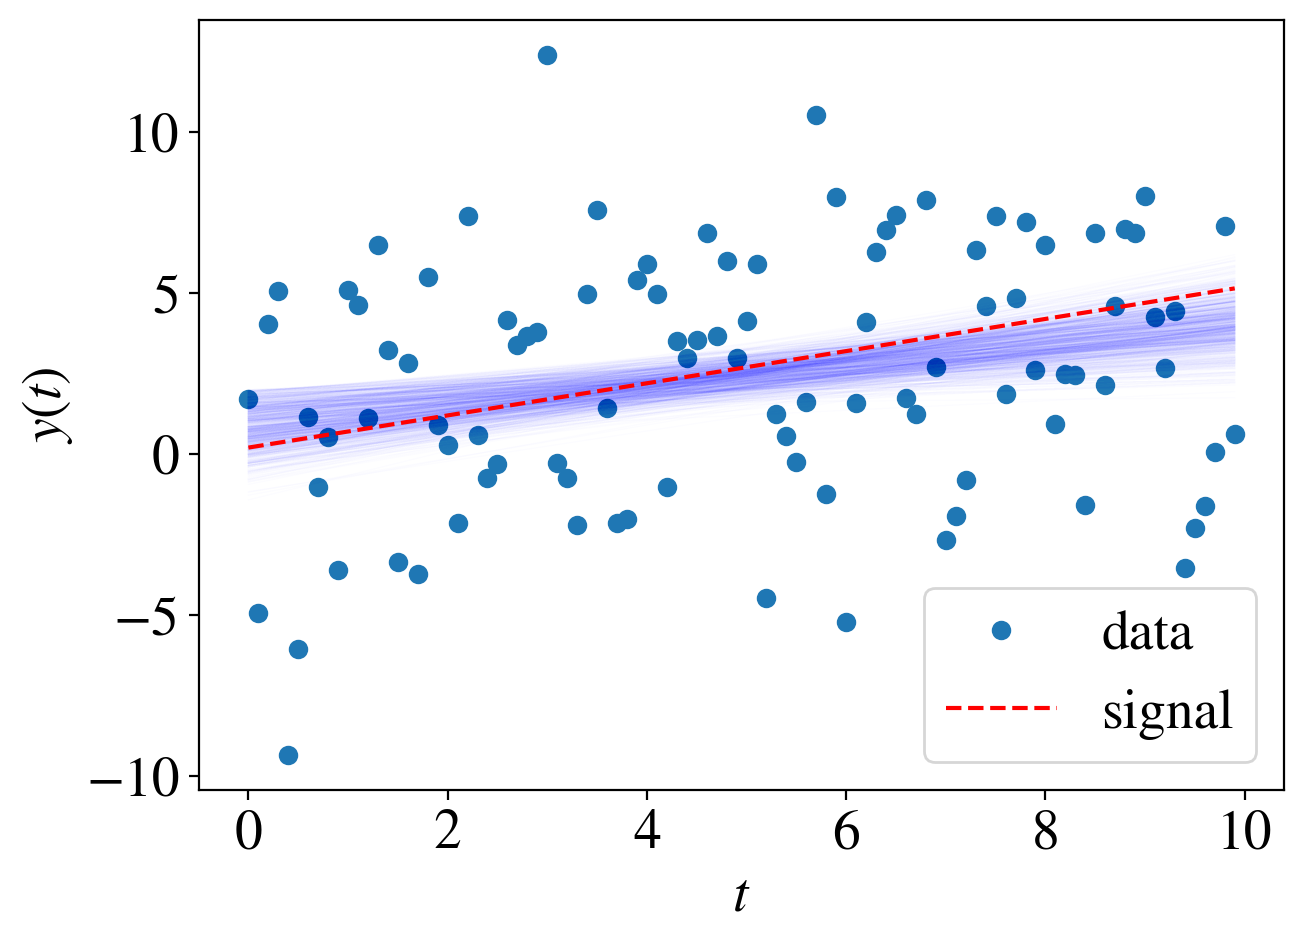

In [18]:
# We quickly plot the data and the inferred parameters to check if fit looks sensible
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(time, data, "o", label="data")
for c, m in zip(posterior_samples['m'], posterior_samples['c']):
    #print(c,m)
    ax.plot(time, model(time, c, m), "b", alpha = 0.1, lw = 0.5) #, label="signal")

ax.plot(time, model(time, injection_parameters['m'], injection_parameters['c']), "--r", label="signal")
ax.set_xlabel("$t$")
ax.set_ylabel("$y(t)$")
ax.legend(fancybox=True)
fig.savefig("{}/{}_data_with_inference.png".format(outdir, label), dpi = 300)

### Questions and exercises

_Hint: rename always the output folder when rerunning with different settings_

- How could you check whether the MCMC converged? plot the MCMC chains which are stored inside `outdir/emcee_linear_regression_unknown_noise/chain.dat`
- what happens if you increase the number of steps? 
- what happens if you increase noise? Rerun the entire notebook by increasing the value of `sigma`.


In [19]:
chain_df = pd.read_csv(f"{outdir}/emcee_{label}/chain.dat", delimiter = '\t')

In [20]:
chain_df

,walker,m,c,sigma,log_l,log_p
0,0,2.452888,-1.589153,11.360361,-381.275369,-5.703782
1,1,0.144998,-1.036688,2.145328,-409.925058,-5.703782
2,2,2.968295,-0.795343,13.246101,-408.985878,-5.703782
3,3,2.015015,-0.900676,5.083330,-416.306392,-5.703782
4,4,0.258290,0.423701,12.022227,-345.787605,-5.703782
...,...,...,...,...,...,...
9995,5,0.275626,1.271930,4.029087,-276.223564,-5.703782
9996,6,0.492348,0.257751,3.738264,-277.342112,-5.703782
9997,7,0.432713,0.990398,4.154086,-278.438049,-5.703782
9998,8,0.278714,1.337914,4.186592,-276.853678,-5.703782


In [21]:
print(f"walkers = {chain_df['walker'].unique()}")



walkers = [0 1 2 3 4 5 6 7 8 9]


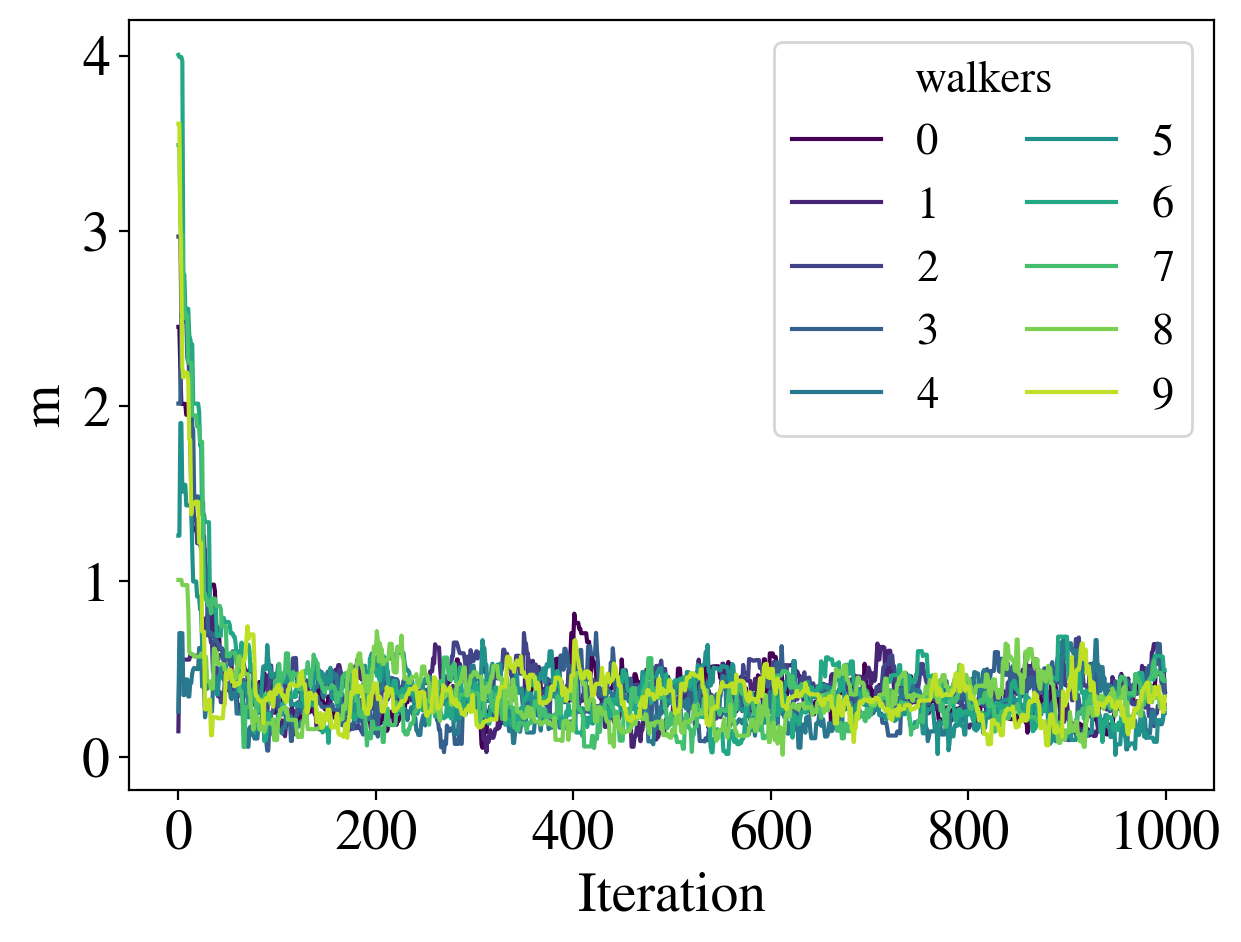

In [22]:
plt.figure(figsize=(7,5))

# fix walker
for i_w, w in enumerate(chain_df['walker'].unique()):
    plt.plot(np.arange(chain_df['m'].loc[chain_df['walker'] == w].shape[0]),
         chain_df['m'].loc[chain_df['walker'] == w], label = w, color = plt.cm.viridis(i_w/chain_df['walker'].unique().shape[0]))

plt.xlabel('Iteration')
plt.ylabel('m')

plt.legend(ncol = 2, title = 'walkers', fontsize = font_value/1.25, title_fontsize = font_value/1.25, fancybox = True)

plt.show()

In [23]:
result_sigma_low = bilby.core.result.read_in_result(f'outdir/linear_regression_unknown_noise_result.json')

In [24]:
result_sigma_low.posterior

,m,c,sigma,log_likelihood,log_prior
0,0.441326,0.419029,0.804984,-115.331174,-3.688879
1,0.433102,0.461194,0.819890,-120.267601,-3.688879
2,0.435229,0.449392,0.802261,-117.105213,-3.688879
3,0.441629,0.428109,0.795234,-115.392298,-3.688879
4,0.452626,0.404489,0.792201,-118.540741,-3.688879
...,...,...,...,...,...
8975,0.438526,0.435160,0.812325,-116.174279,-3.688879
8976,0.450365,0.389246,0.784997,-119.424382,-3.688879
8977,0.441322,0.433947,0.762813,-115.078968,-3.688879
8978,0.419411,0.482994,0.764497,-116.242246,-3.688879


0

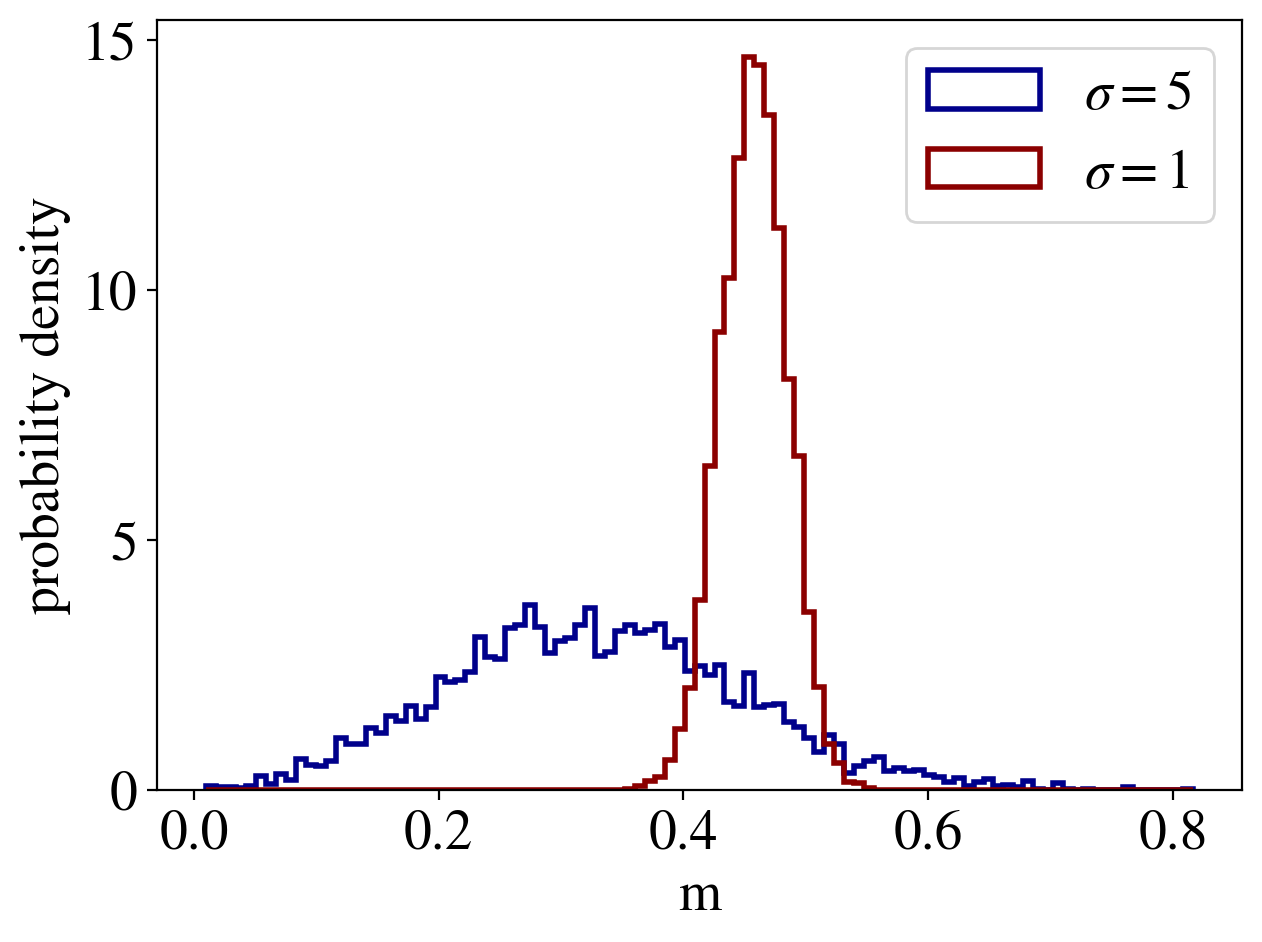

In [36]:
plt.figure(figsize=(7,5))

bins = np.linspace(
    result.posterior['m'].min(), 
    result.posterior['m'].max(), 
    100)

plt.hist(result.posterior['m'], 
         bins = bins,
        histtype='step', lw = 2, color = 'darkblue', label = r'$\sigma = 5$', density = True)

plt.hist(result_sigma_low.posterior['m'], 
         bins = bins,
        histtype='step', lw = 2, color = 'darkred', label = r'$\sigma = 1$', density = True)

plt.ylabel('probability density')
plt.xlabel('m')

plt.legend(fancybox=True)

plt.show()